In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 파일 불러오기

# https://www.kaggle.com/c/titanic/data 에서 데이터셋을 다운
# import seaborn as sns -> sns.load_dataset(('titanic'))

In [ ]:
titanic_df = pd.read_csv('./train.csv')

In [4]:
type(titanic_df)

pandas.core.frame.DataFrame

In [6]:
# 데이터셋 확인 - 최상단 5개, tail() 최하단 5개개
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# 컬럼명 파악
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# 컬럼 설명
Survived - 생존유무, target 값. (0 = 사망, 1 = 생존)

Name - 탑승객 성명

Pclass - 티켓 클래스. (1 = 1st, 2 = 2nd, 3 = 3rd)

Sex - 성별

Age - 나이(세)

SibSp - 함께 탑승한 형제자매, 배우자 수 총합

Parch - 함께 탑승한 부모, 자녀 수 총합

Embarked - 탑승 항구

Fare - 탑승 요금

Ticket - 티켓 넘버

Cabin - 객실 넘버

In [9]:
# 데이터 프레임 구조(행, 열) 크기 파악
titanic_df.shape

(891, 12)

In [10]:
# 정보 파악
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


전체 행의 길이는 891인데 Age, Cabin, Embarked의 개수는 891개가 되지 않는 것을 확인할 수 있다.

-> 결측치가 있다는 것!

In [11]:
titanic_df.isnull().sum()

# isnull()과 sum()을 함께 쓰면, 각 칼럼별 결측치의 개수를 알 수 있음
# isnull()을 단독으로 쓰면 각 원소별로 null값인지 아닌지 boolean형태로 출력

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# 데이터 컬럼별 통계량 요약
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
# 생존 여부 feature
# 0은 사망(death), 1은 생존(survived)
titanic_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [27]:
titanic_df.groupby('Sex').sum()['Survived']
# groupby()를 사용하여 특정 칼럼의 정보만 얻을 수 있다. 
# 해당 코드는 성별 생존자수를 구하기 위해 집계함수 sum()도 같이 사용

Sex
female    233
male      109
Name: Survived, dtype: int64

C:\Users\hunky\AppData\Local\Temp\ipykernel_31168\2608814352.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set(xlabel='', xticklabels=labels)


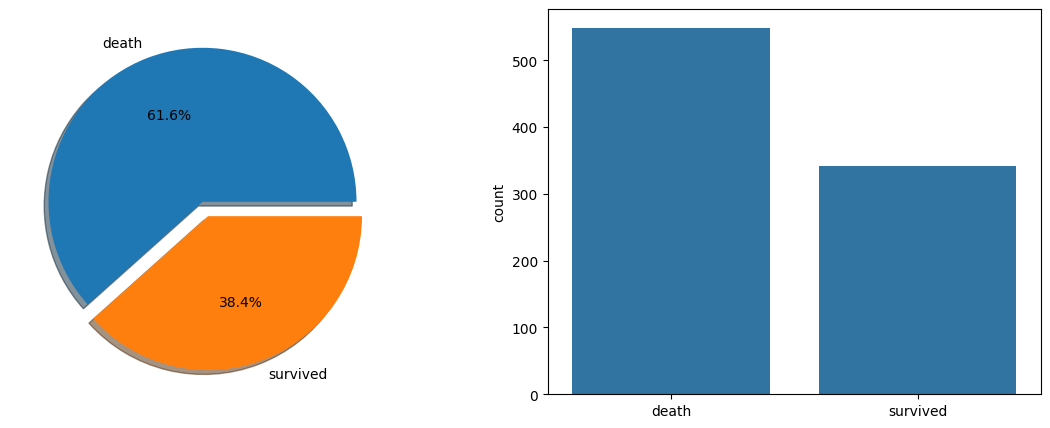

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
labels = ['death', 'survived']
 
# Pie Plot
titanic_df['Survived'].value_counts().plot.pie(ax=ax[0], explode=[0,0.1], shadow=True, autopct='%1.1f%%', labels=labels)
ax[0].set(ylabel='')
 
# Count Plot
sns.countplot(data=titanic_df, x='Survived', ax=ax[1])
ax[1].set(xlabel='', xticklabels=labels)
 
plt.show()

In [31]:
# 좌석 등급 비율
# 1등석, 2등석, 3등석
titanic_df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [37]:
#Groupby를 이용한 Pclass에 따른 Survived의 평균
titanic_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


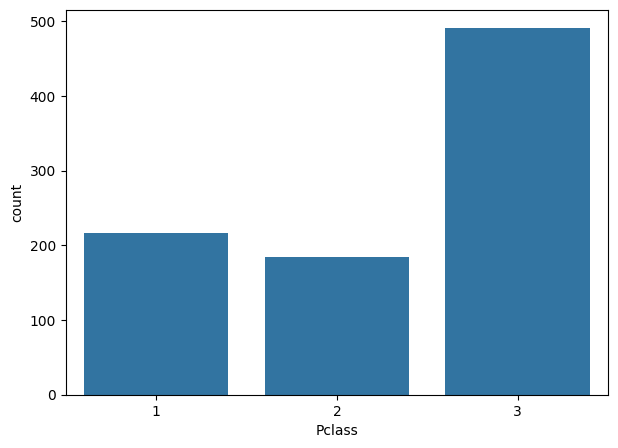

In [32]:
fig, ax = plt.subplots(figsize=(7,5))
 
sns.countplot(data=titanic_df, x='Pclass', ax=ax)
 
plt.show()

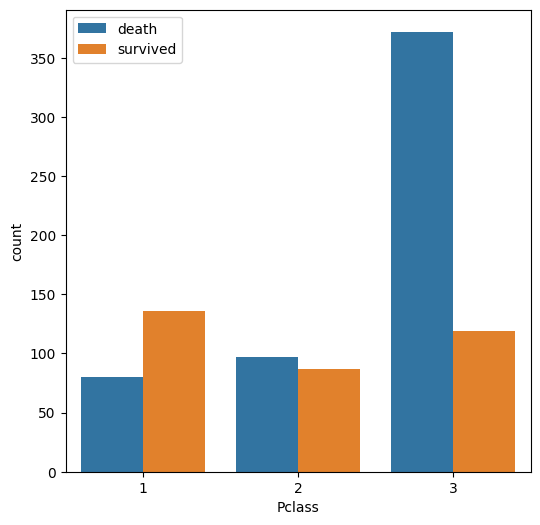

In [38]:
fig, ax = plt.subplots(figsize=(6,6))
 
sns.countplot(data=titanic_df, x='Pclass', hue='Survived', ax=ax)
 
#범례 한글로 변경
labels=['death', 'survived']
ax.legend(labels=labels)
 
plt.show()

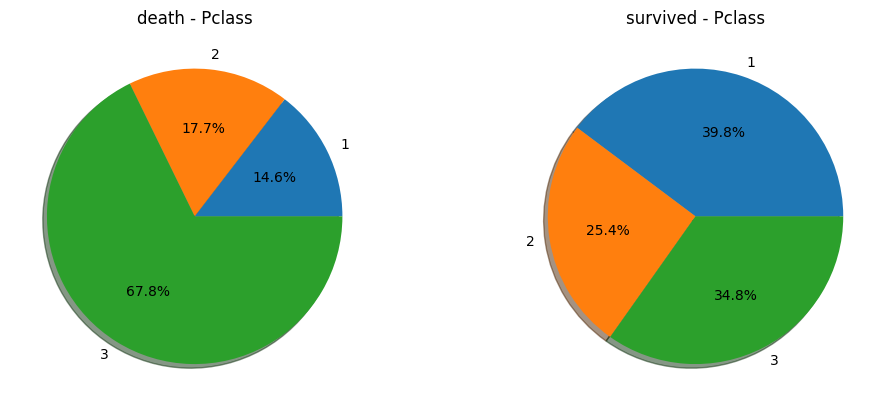

In [40]:
fig, ax = plt.subplots(1,2,figsize=(10,4), constrained_layout=True)
 
 
#Survived 가 0인 데이터를 이용한 Pie Plot
titanic_df[titanic_df['Survived'] == 0]['Pclass'].value_counts().sort_index().plot.pie(ax=ax[0], shadow=True, autopct='%1.1f%%')
ax[0].set(ylabel='', title='death - Pclass')
 
#Survived 가 1인 데이터를 이용한 Pie Plot
titanic_df[titanic_df['Survived'] == 1]['Pclass'].value_counts().sort_index().plot.pie(ax=ax[1], shadow=True, autopct='%1.1f%%')
ax[1].set(ylabel='', title='survived - Pclass')
 
plt.show()

#### 결측치 채우기

전체 칼럼에 대해서 결측치를 채우고 싶다면 titanic_df.fillna(대체하고싶은 값)을 사용하면 되지만,

타이타닉 데이터셋은 결측치가 있는 칼럼이 요구하는 값들이 다르기 때문에 칼럼별로 결측치를 채워보고자 한다.

In [14]:
# Age칼럼 - 평균으로 채우기
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)

C:\Users\hunky\AppData\Local\Temp\ipykernel_31168\199946875.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)


inplace는 변경 값을 저장할 때 True 값을 준다.

데이터프레임의 데이터를 바로 변경하고 싶으면 True옵션을 주면 된다.

쉽게 말해서 inplace=True는 바뀐 데이터가 바로 반영이 되는 것이고, inplace=False는 바뀐 데이터가 반영이 안된다는 것으로 이해를 하면 되겠다.

In [16]:
#Cabin칼럼 - N으로 채우기
titanic_df['Cabin'].fillna('N', inplace=True)

C:\Users\hunky\AppData\Local\Temp\ipykernel_31168\1451161741.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Cabin'].fillna('N', inplace=True)


In [17]:
# Embarked칼럼 - N으로 채우기
titanic_df['Embarked'].fillna('N', inplace=True)

C:\Users\hunky\AppData\Local\Temp\ipykernel_31168\2302967287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Embarked'].fillna('N', inplace=True)


In [18]:
# 연령대 별 생존자 확인을 위한 함수

def change_age(age):
    age = int(age)
    if age >= 70:
        return '노인'
    elif age >= 10:
        return str(age//10) + '0대'
    else:
        return '유아'

In [19]:
# 위와 같은 함수를 데이터프레임에 적용 -> apply()
# 새로운 칼럼 AgeRange에 연령대가 저장
titanic_df['AgeRange'] = titanic_df['Age'].apply(change_age)

In [20]:
# 연령대별 생존 여부 확인
titanic_df.groupby('AgeRange').sum()['Survived']

AgeRange
10대     41
20대    129
30대     73
40대     34
50대     20
60대      6
노인       1
유아      38
Name: Survived, dtype: int64